In [9]:
from pathlib import Path

# Each eval dir is one timestamped output directory written by compute_metrics_junction_detection_nnunet_landmark.py
# containing metrics.csv and predictions_nnunet_landmark.csv. The per-case probability-map
# .npz/.json outputs (from nnunet_landmark_predict_from_files(..., save_probabilities=True))
# are copied alongside these into a subfolder of eval_out_dir named after the nnU-Net trainer,
EVAL_DIRS: list[tuple[str, Path]] = [
    ("nnUNetTrainerHeatmapMSE", Path(
        "/mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/20260821_122911")),
    ("nnUNetTrainerHeatmapAdaptiveWing", Path(
        "/mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/20260824_091448")),
]

PLOT_PROBABILITY_MAPS = True

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [11]:
def bold_best(df: pd.DataFrame, lower_is_better_cols: set[str] | None = None):
    """Return a Styler that bolds the best value in each column."""
    lower_is_better_cols = lower_is_better_cols or set()

    def _apply(s: pd.Series) -> list[str]:
        numeric = pd.to_numeric(s, errors="coerce")
        want_min = s.name in lower_is_better_cols
        best = numeric.min() if want_min else numeric.max()
        return [
            "font-weight: bold" if (not np.isnan(v) and v == best) else ""
            for v in numeric
        ]

    float_cols = df.select_dtypes(include="number").columns
    fmt = {c: "{:.4f}" for c in float_cols}
    return (
        df.style
        .apply(_apply, axis=0)
        .format(fmt, na_rep="\u2013")
        .set_table_styles([{"selector": "th, td", "props": "font-family: inherit; font-size: inherit;"}])
    )


def horizontal_bar_groups(df: pd.DataFrame, col_groups: list[tuple],
                          lower_is_better: set[str] | None = None,
                          col_rename: dict | None = None,
                          ylim: tuple | None = (0, 1.18),
                          cols_per_row: int | None = None,
                          suptitle: str = "") -> None:
    """Bar chart grid, one subplot per column group.  Legend is placed above the figure.

    Parameters
    ----------
    ylim         : (ymin, ymax) or None to auto-scale each subplot independently.
    cols_per_row : max subplots per row; None keeps all groups in a single row.
    """
    from matplotlib.gridspec import GridSpec

    lower_is_better = lower_is_better or set()
    col_rename = col_rename or {}

    filtered_groups = [
        [c for c in group if c in df.columns]
        for group in col_groups
    ]
    filtered_groups = [g for g in filtered_groups if g]
    if not filtered_groups:
        print("  (no columns available for bar chart)")
        return

    model_labels = [str(n) for n in df.index]
    total_cols = sum(len(g) for g in filtered_groups)
    colors = plt.cm.tab10(np.linspace(0, 0.9, len(df)))

    # Split groups into rows
    cpr = cols_per_row or len(filtered_groups)
    row_chunks = [filtered_groups[i:i + cpr]
                  for i in range(0, len(filtered_groups), cpr)]
    n_rows = len(row_chunks)

    ncol = min(len(df), 4)
    n_legend_rows = (len(df) + ncol - 1) // ncol
    top_gap = 0.05 * n_legend_rows + (0.07 if suptitle else 0.03)
    subplot_top = 1.2 - top_gap

    row_height = max(4, len(df) * 0.5 + 1.5)
    fig_width = max(10, 2.0 * total_cols)
    fig_height = row_height * n_rows

    fig = plt.figure(figsize=(fig_width, fig_height))
    outer_gs = GridSpec(n_rows, 1, figure=fig, hspace=0.45)

    first_handles, first_labels = None, None

    for row_idx, chunk in enumerate(row_chunks):
        width_ratios = [len(g) for g in chunk]
        inner_gs = outer_gs[row_idx].subgridspec(
            1, len(chunk), width_ratios=width_ratios, wspace=0.3)

        for ci, cols in enumerate(chunk):
            ax = fig.add_subplot(inner_gs[0, ci])
            x = np.arange(len(cols))
            width = 0.8 / max(len(df), 1)

            bars_by_col: dict[int, list[tuple]] = {
                k: [] for k in range(len(cols))}

            for i, (model, row) in enumerate(df.iterrows()):
                vals = [float(row.get(c, np.nan)) for c in cols]
                offset = (i - len(df) / 2 + 0.5) * width
                rects = ax.bar(x + offset, vals, width * 0.9,
                               label=model_labels[i], color=colors[i])
                for k, (rect, val) in enumerate(zip(rects, vals)):
                    bars_by_col[k].append((val, rect))

            if first_handles is None:
                first_handles, first_labels = ax.get_legend_handles_labels()

            # Annotation offset relative to data range
            all_vals = [v for entries in bars_by_col.values()
                        for v, _ in entries if not np.isnan(v)]
            y_range = (max(all_vals) - min(all_vals)
                       ) if len(all_vals) >= 2 else 1.0
            ann_offset = y_range * 0.025

            for k, col in enumerate(cols):
                entries = [(v, r)
                           for v, r in bars_by_col[k] if not np.isnan(v)]
                if not entries:
                    continue
                want_min = col in lower_is_better
                best_val, best_rect = (min(entries, key=lambda t: t[0]) if want_min
                                       else max(entries, key=lambda t: t[0]))
                bar_x = best_rect.get_x() + best_rect.get_width() / 2
                ax.text(bar_x, best_rect.get_height() + ann_offset,
                        f"{best_val:.3f}",
                        ha="center", va="bottom", fontsize=7, fontweight="bold")

            tick_labels = [col_rename.get(
                c, c).replace(" ", "\n") for c in cols]
            ax.set_xticks(x)
            ax.set_xticklabels(tick_labels, fontsize=8)
            ax.grid(axis="y", linestyle="--", alpha=0.4)

            if ylim is not None:
                ax.set_ylim(*ylim)
            else:
                if all_vals:
                    ax.set_ylim(0, max(all_vals) + y_range * 0.15)

    plt.tight_layout(rect=[0, 0, 1, subplot_top])
    fig.legend(
        first_handles, first_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, subplot_top),
        ncol=ncol,
        fontsize=8,
        framealpha=0.8,
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=0.99)

    plt.show()
    plt.close()

## Load Metrics

In [12]:
# Each metrics.csv is a single row (one model/run per compute_metrics_junction_detection_nnunet_landmark.py
# invocation), so we stack one row per (label, eval_out_dir) pair into a single dataframe indexed by label.
_rows = {}
for trainer, eval_dir in EVAL_DIRS:
    csv_path = eval_dir / "metrics.csv"
    if not csv_path.is_file():
        raise FileNotFoundError(f"metrics.csv not found for '{trainer}' in {eval_dir}")
    df_one = pd.read_csv(csv_path)
    if len(df_one) != 1:
        raise ValueError(f"Expected a single-row metrics.csv for '{trainer}', got {len(df_one)} rows")
    _rows[trainer] = df_one.iloc[0]

df_jd = pd.DataFrame(_rows).T
df_jd.index.name = "Model"
print(f"Loaded junction detection metrics for {len(df_jd)} model(s):")
for trainer, eval_dir in EVAL_DIRS:
    print(f"  {trainer}: {eval_dir}")

Loaded junction detection metrics for 2 model(s):
  nnUNetTrainerHeatmapMSE: /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/20260821_122911
  nnUNetTrainerHeatmapAdaptiveWing: /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/20260824_091448


In [13]:
# Ground truth junction counts (informative only - not asserted equal, since different
# runs being compared could in principle have evaluated different test sets)
print("Ground truth junctions in test set per model:")
for trainer in df_jd.index:
    n3 = int(df_jd.loc[trainer, "gt_3way_total"])
    n4 = int(df_jd.loc[trainer, "gt_4way_total"])
    print(f"  {trainer}: 3-way={n3}  4-way={n4}  total={n3 + n4}")

Ground truth junctions in test set per model:
  nnUNetTrainerHeatmapMSE: 3-way=45  4-way=77  total=122
  nnUNetTrainerHeatmapAdaptiveWing: 3-way=45  4-way=77  total=122


In [14]:
# Derive a micro-averaged "joint" combined metric (both classes summed) from the
# per-class counts already in the CSV.
def _prf(tp, fp, fn):
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return prec, rec, f1

tp = df_jd["class_tp_3way"] + df_jd["class_tp_4way"]
fp = df_jd["class_fp_3way"] + df_jd["class_fp_4way"]
fn = df_jd["class_fn_3way"] + df_jd["class_fn_4way"]
prf = [_prf(tp.iloc[i], fp.iloc[i], fn.iloc[i]) for i in range(len(df_jd))]
df_jd["class_tp_combined"]        = tp.values
df_jd["class_fp_combined"]        = fp.values
df_jd["class_fn_combined"]        = fn.values
df_jd["class_precision_combined"] = [p for p, _, _ in prf]
df_jd["class_recall_combined"]    = [r for _, r, _ in prf]
df_jd["class_f1_combined"]        = [f for _, _, f in prf]

In [15]:
# Column groups - all higher-is-better
_JD_LOCALISATION      = ["precision_loc", "recall_loc", "f1_loc"]
_JD_DETECTION_RECALL  = ["detection_recall_3way", "detection_recall_4way"]
_JD_TYPE_OVERALL      = ["type_accuracy"]
_JD_CLASS_COMBINED    = ["class_precision_combined", "class_recall_combined", "class_f1_combined"]
_JD_CLASS_3WAY        = ["class_precision_3way", "class_recall_3way", "class_f1_3way"]
_JD_CLASS_4WAY        = ["class_precision_4way", "class_recall_4way", "class_f1_4way"]

_JD_DISPLAY_COLS = (
    _JD_LOCALISATION + _JD_DETECTION_RECALL + _JD_TYPE_OVERALL
    + _JD_CLASS_COMBINED + _JD_CLASS_3WAY + _JD_CLASS_4WAY
)

_DISPLAY_RENAME = {
    "precision_loc":            "Precision (loc)",
    "recall_loc":               "Recall (loc)",
    "f1_loc":                   "F1 (loc)",
    "detection_recall_3way":    "Det. Recall 3-way",
    "detection_recall_4way":    "Det. Recall 4-way",
    "type_accuracy":            "Type Accuracy",
    "class_precision_combined": "Precision (joint)",
    "class_recall_combined":    "Recall (joint)",
    "class_f1_combined":        "F1 (joint)",
    "class_precision_3way":     "Precision 3-way",
    "class_recall_3way":        "Recall 3-way",
    "class_f1_3way":            "F1 3-way",
    "class_precision_4way":     "Precision 4-way",
    "class_recall_4way":        "Recall 4-way",
    "class_f1_4way":            "F1 4-way",
}


def _jd_table(df: pd.DataFrame, title: str) -> None:
    cols_in_df = [c for c in _JD_DISPLAY_COLS if c in df.columns]
    if not cols_in_df:
        print("No junction detection metric columns found.")
        return
    display(HTML(f"<h4>{title}</h4>"))
    sub = df[cols_in_df].copy()
    sub.columns = [_DISPLAY_RENAME.get(c, c) for c in cols_in_df]
    display(bold_best(sub))

**Precision / Recall / F1 (loc):** class-agnostic; a prediction is a TP if it falls within the pixel threshold of *any* GT junction, regardless of type.
**Det. Recall 3-way / 4-way:** per-GT-class localisation recall - of all GT junctions of that type, what fraction were spatially matched by *any* prediction (regardless of predicted type). Also shown in the confusion matrix title.
**Type Accuracy:** among spatially-matched TPs only - fraction whose type label (3-way / 4-way) matches GT.
**Precision / Recall / F1 (joint):** micro-averaged over both classes; a prediction is a TP for class $c$ only if it is both correctly localised *and* correctly labelled - equivalent to summing the per-class TP/FP/FN counts before computing the metrics.
**Precision / Recall / F1 3-way & 4-way:** same joint criterion, broken out per class. FP and FN include both spurious/missed detections and type misclassifications (see confusion matrices below).

Predictions come from `"Normal Fork"` heatmap peaks (matched to 3-way GT) and combined `"Reversed Fork / Crossing"` heatmap peaks (matched to 4-way GT) - see `compute_metrics_junction_detection_nnunet_landmark.py`.

### Junction Detection Metrics

In [16]:
_jd_table(df_jd, title="nnU-Net Landmark (Heatmap Regression) - Junction Detection")

,Precision (loc),Recall (loc),F1 (loc),Det. Recall 3-way,Det. Recall 4-way,Type Accuracy,Precision (joint),Recall (joint),F1 (joint),Precision 3-way,Recall 3-way,F1 3-way,Precision 4-way,Recall 4-way,F1 4-way
Model,,,,,,,,,,,,,,,
nnUNetTrainerHeatmapMSE,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
nnUNetTrainerHeatmapAdaptiveWing,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


### Junction Detection Bar Charts

/tmp/ipykernel_3282/947086330.py:131: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, subplot_top])


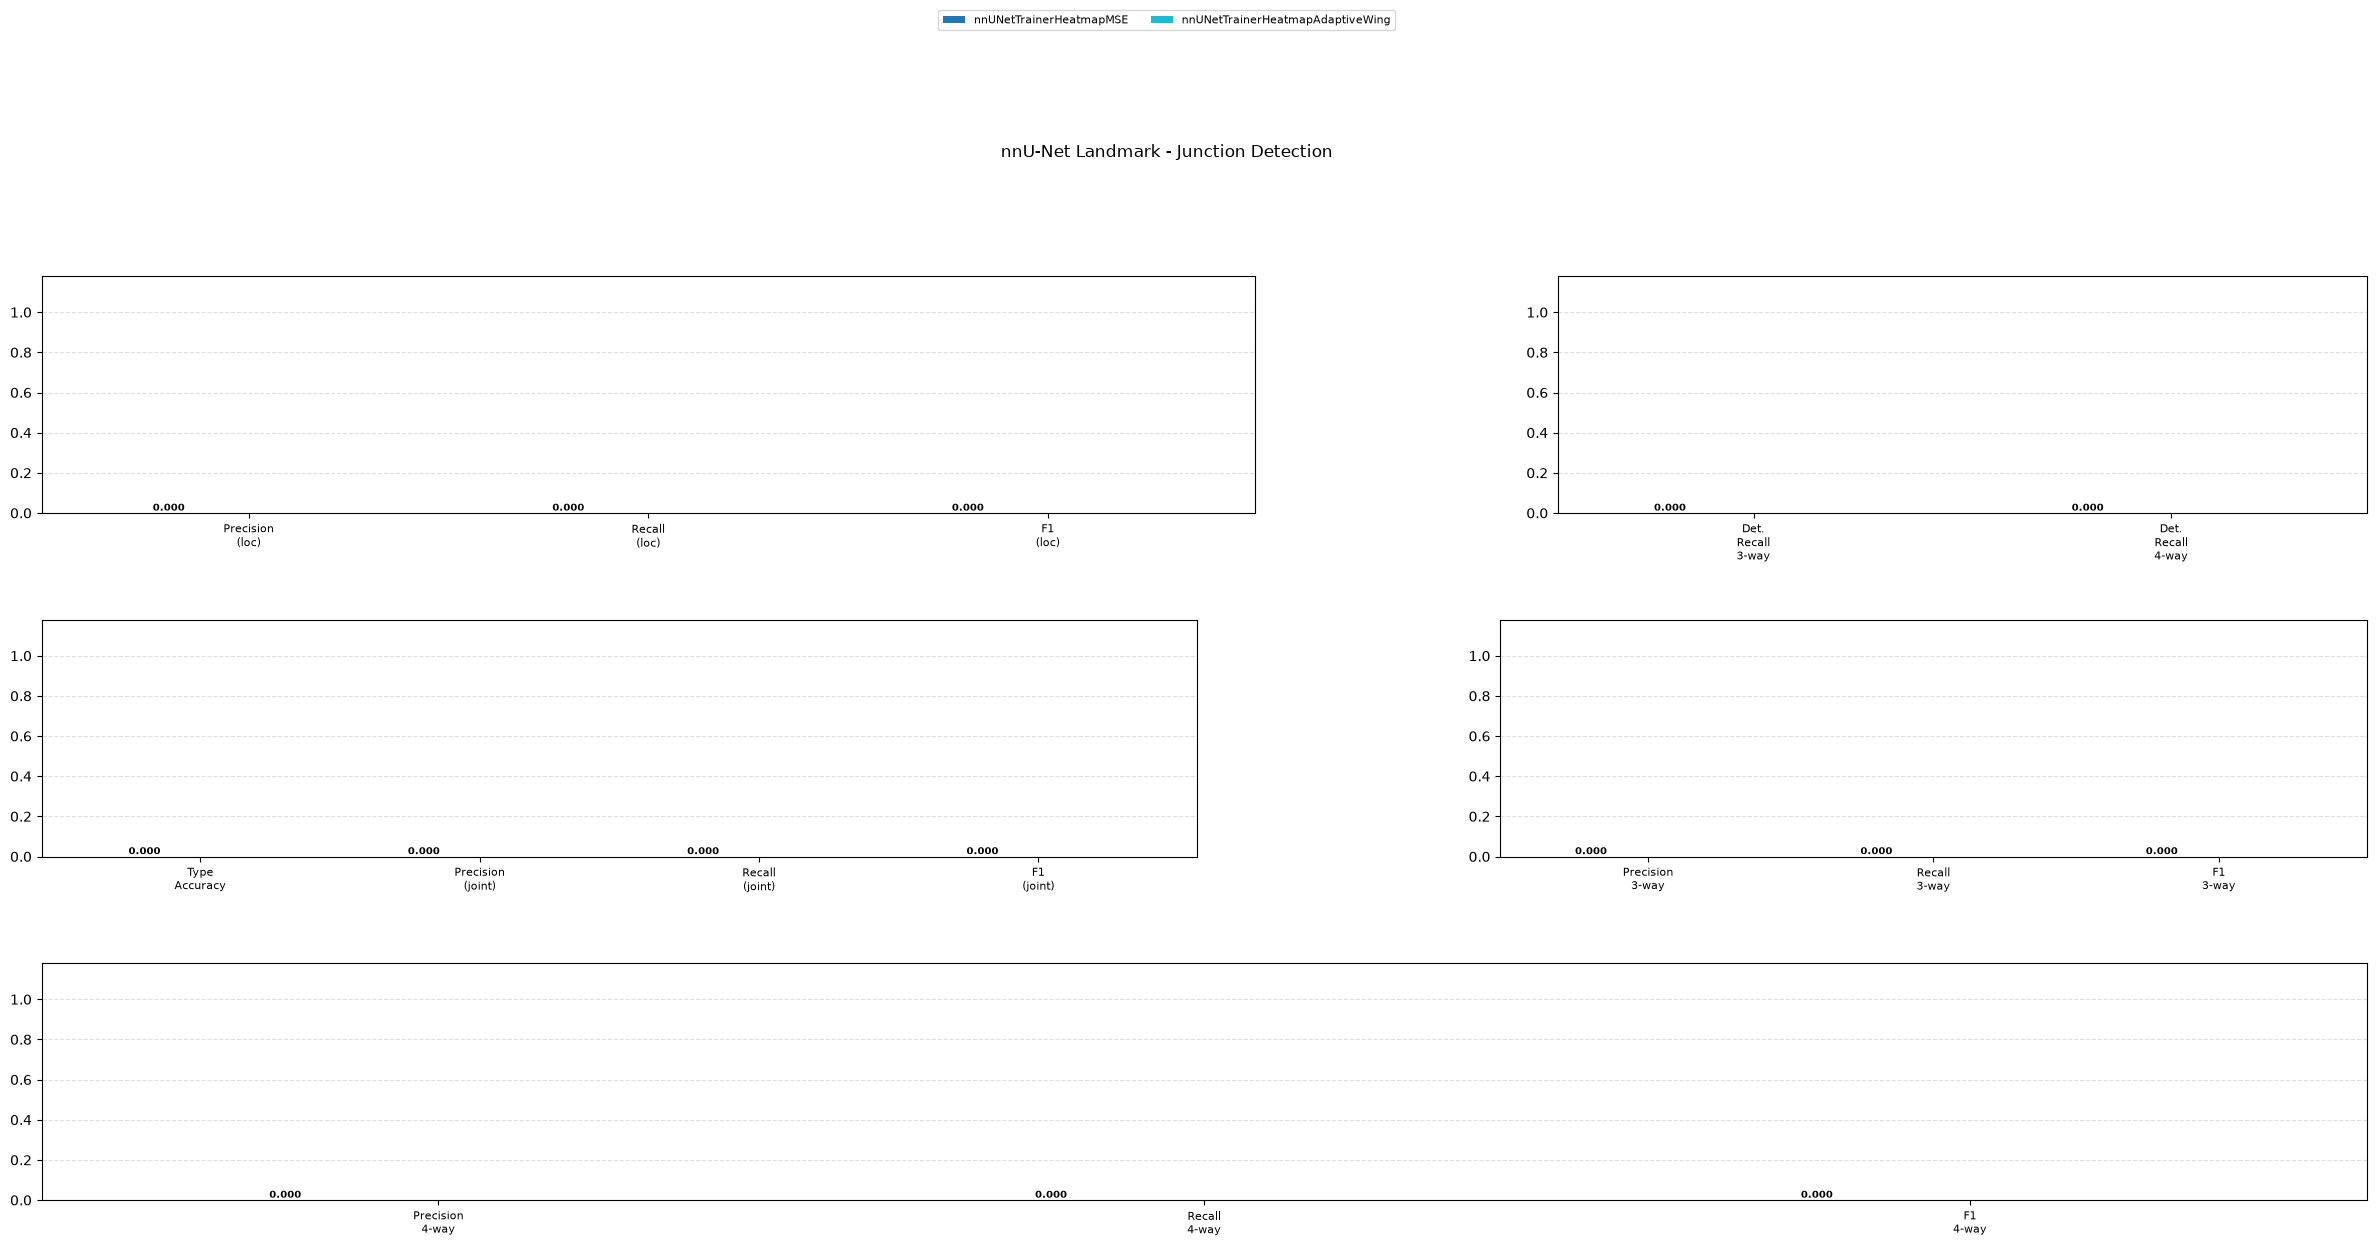

In [17]:
horizontal_bar_groups(
    df_jd,
    col_groups=[
        tuple(_JD_LOCALISATION),
        tuple(_JD_DETECTION_RECALL),
        tuple(_JD_TYPE_OVERALL + _JD_CLASS_COMBINED),
        tuple(_JD_CLASS_3WAY),
        tuple(_JD_CLASS_4WAY),
    ],
    col_rename=_DISPLAY_RENAME,
    cols_per_row=2,
    suptitle="nnU-Net Landmark - Junction Detection",
)

### Confusion Matrices

Rows = GT outcome (3-way / 4-way / no GT). Columns = prediction outcome (pred 3-way / pred 4-way / not found). Cell % is row-normalised.

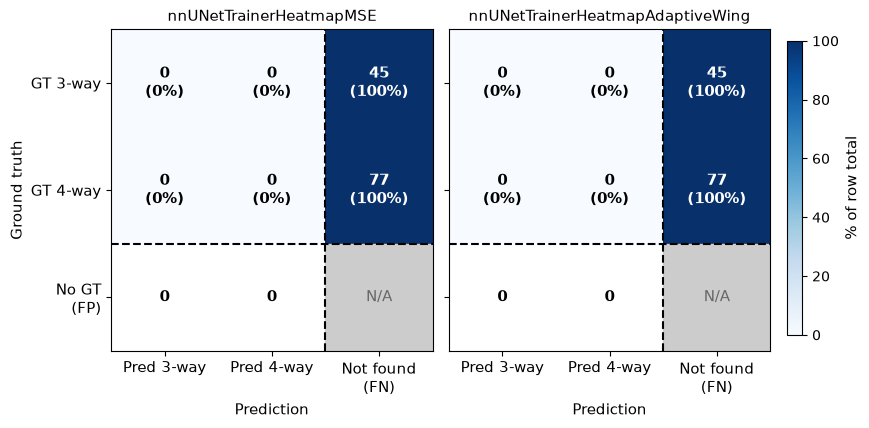

In [ ]:
_CM_FONT = 11
_CM_COL_LABELS = ["Pred 3-way", "Pred 4-way", "Not found\n(FN)"]
_CM_ROW_LABELS = ["GT 3-way", "GT 4-way", "No GT\n(FP)"]


def _plot_cm_from_row(ax, row, title, show_x_labels=True, show_y_labels=True):
    cm = np.array([
        [row["cm_gt3_pred3"], row["cm_gt3_pred4"], row["fn_3way"]],
        [row["cm_gt4_pred3"], row["cm_gt4_pred4"], row["fn_4way"]],
        [row["fp_3way"],      row["fp_4way"],      float("nan")],
    ], dtype=float)

    row_totals = np.array([
        row["gt_3way_total"],
        row["gt_4way_total"],
        row["fp_3way"] + row["fp_4way"],
    ], dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        cm_pct = np.where(row_totals[:, None] > 0,
                          100.0 * cm / row_totals[:, None],
                          np.nan)

    masked = np.ma.masked_invalid(cm_pct)
    im = ax.imshow(masked, cmap="Blues", vmin=0, vmax=100, aspect="equal")

    ax.add_patch(plt.Rectangle((1.5, 1.5), 1, 1, color="#cccccc", zorder=2))
    ax.text(2, 2, "N/A", ha="center", va="center",
            fontsize=_CM_FONT, color="#666666", zorder=3)

    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(_CM_COL_LABELS if show_x_labels else [""] * 3, fontsize=_CM_FONT)
    ax.set_yticklabels(_CM_ROW_LABELS if show_y_labels else [""] * 3, fontsize=_CM_FONT)
    if show_x_labels:
        ax.set_xlabel("Prediction", fontsize=_CM_FONT)
    if show_y_labels:
        ax.set_ylabel("Ground truth", fontsize=_CM_FONT)

    for r in range(3):
        for c in range(3):
            if r == 2 and c == 2:
                continue
            val = cm[r, c]
            if np.isnan(val):
                continue
            pct = cm_pct[r, c]
            pct_str = f"\n({pct:.0f}%)" if not np.isnan(pct) else ""
            text_color = "white" if (not np.isnan(pct) and pct > 60) else "black"
            ax.text(c, r, f"{int(val)}{pct_str}",
                    ha="center", va="center",
                    fontsize=_CM_FONT, color=text_color, fontweight="bold", zorder=4)

    ax.axhline(1.5, color="black", linewidth=1.5, linestyle="--")
    ax.axvline(1.5, color="black", linewidth=1.5, linestyle="--")
    ax.set_title(title, fontsize=_CM_FONT)
    return im


_cols = 2
_rows = (len(df_jd) + _cols - 1) // _cols
fig, axes = plt.subplots(_rows, _cols, figsize=(4.2 * _cols, 4.2 * _rows), squeeze=False)

im = None
for i, trainer in enumerate(df_jd.index):
    r, channel = i // _cols, i % _cols
    ax = axes[r][channel]
    im = _plot_cm_from_row(
        ax, df_jd.loc[trainer], str(trainer),
        show_x_labels=(r == _rows - 1),
        show_y_labels=(channel == 0),
    )

for ax in axes.flat[len(df_jd):]:
    ax.set_visible(False)

plt.subplots_adjust(wspace=0.05, hspace=0.15, right=0.91)

cbar_ax = fig.add_axes([0.93, 0.15, 0.018, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("% of row total", fontsize=_CM_FONT)
cbar.ax.tick_params(labelsize=_CM_FONT - 1)

plt.show()
plt.close()

In [ ]:
from skimage.feature import peak_local_max

trainer = "nnUNetTrainerHeatmapAdaptiveWing"
sample = "Dani-Funghi-TileSet-6-Tile-010-012"

eval_dir = next(e for e in EVAL_DIRS if e[0] == trainer)
print(eval_dir)

npz_path = eval_dir[1] / trainer / f"{sample}.npz"
# saved as float16 to save disk space; peak_local_max (via scipy) doesn't support float16
probabilities = np.load(npz_path)['probabilities'].astype(np.float32)
print(probabilities.shape)

points_by_channel: dict[int, list[tuple]] = {}
for channel in range(0, probabilities.shape[0]):
    channel_map = np.squeeze(probabilities[channel])

    # print(f"channel {channel}:\n==========")
    # rows, cols = np.where(channel_map > 0.5)
    # for row, col in zip(rows, cols):
    #    print(f"({row},{col}): {channel_map[row, col]}")
    # print()

    coords = peak_local_max(
        channel_map, min_distance=3, threshold_abs=0.5)
    points_by_channel[channel] = [(int(x), int(y), float(
        channel_map[y, x])) for y, x in coords]

print(points_by_channel)

('nnUNetTrainerHeatmapAdaptiveWing', PosixPath('/mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/20260824_091448'))
(3, 1, 1024, 1024)
{0: [(217, 945, 0.939453125)], 1: [(217, 945, 0.578125)], 2: [(217, 945, 0.9375)]}


In [ ]:
if PLOT_PROBABILITY_MAPS:
    from matplotlib.colors import LinearSegmentedColormap

    # white (0 probability) -> red (1 probability)
    _white_to_red = LinearSegmentedColormap.from_list(
        "white_to_red", ["#ffffff", "#ff0000"])

    # Channel order matches create_nnunet_heatmap_dataset.get_label_mapping(combine_reversed_crossing=True):
    # 0 = background/combined (skipped), 1 = Normal Fork, 2 = Reversed Fork / Crossing
    _PROB_MAP_CHANNEL_LABELS = {
        1: "Normal Fork (3-way)",
        2: "Reversed Fork / Crossing (4-way)",
    }

    for trainer, eval_dir in EVAL_DIRS:
        prob_map_source_dir = eval_dir / trainer
        prob_map_plot_out_dir = eval_dir / "plot" / trainer

        _npz_paths = sorted(prob_map_source_dir.glob("*.npz"))
        if not _npz_paths:
            print(
                f"[{trainer}] No .npz probability maps found in {prob_map_source_dir}")
            continue

        prob_map_plot_out_dir.mkdir(parents=True, exist_ok=True)

        for npz_path in _npz_paths:
            case_id = npz_path.stem
            probabilities = np.load(
                npz_path)["probabilities"].astype(np.float32)
            # revert_heatmap_to_original_geometry keeps a singleton z-axis for 2D configs
            # (shape (C, 1, H, W)); drop it so each channel is a plain (H, W) image.
            if probabilities.ndim == 4 and probabilities.shape[1] == 1:
                probabilities = probabilities[:, 0]

            channels = [c for c in _PROB_MAP_CHANNEL_LABELS if c <
                        probabilities.shape[0]]
            fig, axes = plt.subplots(1, len(channels), figsize=(
                6 * len(channels), 6), squeeze=False)
            axes = axes[0]

            for ax, channel in zip(axes, channels):
                im = ax.imshow(
                    probabilities[channel], cmap=_white_to_red, vmin=0.0, vmax=1.0)
                ax.set_title(_PROB_MAP_CHANNEL_LABELS[channel], fontsize=10)
                ax.axis("off")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            fig.suptitle(f"{trainer} - {case_id}", fontsize=11)
            plt.tight_layout()
            out_path = prob_map_plot_out_dir / f"{case_id}.png"
            fig.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.close(fig)

        print(
            f"[{trainer}] Saved {len(_npz_paths)} probability map plot(s) to {prob_map_plot_out_dir}")
else:
    print("PLOT_PROBABILITY_MAPS is False - skipping probability map plots.")

[nnUNetTrainerHeatmapMSE] Saved 100 probability map plot(s) to /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/20260821_122911/plot/nnUNetTrainerHeatmapMSE
[nnUNetTrainerHeatmapAdaptiveWing] Saved 100 probability map plot(s) to /mnt/c/Users/juhe9/repos/MasterThesis/ForkSight/Data/nnunet_landmark_eval_output/20260824_091448/plot/nnUNetTrainerHeatmapAdaptiveWing
